In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

In [3]:
project_root = Path().resolve().parent

# добавляем в sys.path
sys.path.append(str(project_root))

from core.graf import *
from core.func import *

In [4]:
data_path = "../data/News_Category_Dataset_v3.json"

with open(data_path, 'r') as file:
    data = pd.DataFrame([json.loads(line) for line in file])

data.sample(5)

,link,headline,category,short_description,authors,date
44492,https://www.huffingtonpost.com/entry/japanese-...,Remember WWII? Scapegoating Was The Wrong Answ...,POLITICS,"We asked Japanese-Americans, some of whom were...",Ryan Grenoble,2017-01-30
136388,https://www.huffingtonpost.com/entry/4-good-wa...,4 Good Ways to Cope With Fear,WELLNESS,We don't want to live in a world where planes ...,"David Kessler, Contributor\nAuthor, grief and ...",2014-03-19
141344,https://www.huffingtonpost.comhttp://www.nytim...,Pipeline Fight Lifts Environmental Movement,ENVIRONMENT,WASHINGTON — Environmentalists have spent the ...,,2014-01-25
134523,https://www.huffingtonpost.com/entry/little-ki...,Kids' First Judo Fight Is More Like A Series O...,PARENTING,Maybe soon the two adorable kids will take up ...,Ryan Grenoble,2014-04-08
105630,https://www.huffingtonpost.com/entry/men-narci...,Science Confirms That Men Are The More Narciss...,SCIENCE,,Carolyn Gregoire,2015-03-06


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   link               209527 non-null  str  
 1   headline           209527 non-null  str  
 2   category           209527 non-null  str  
 3   short_description  209527 non-null  str  
 4   authors            209527 non-null  str  
 5   date               209527 non-null  str  
dtypes: str(6)
memory usage: 9.6 MB


In [6]:
data.duplicated().sum()

np.int64(13)

In [7]:
data.isna().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

# Старт EDA

In [8]:
eda_data = data.copy()

In [9]:
eda_data.drop_duplicates(inplace=True)

In [ ]:
eda_data["headline"] = eda_data["headline"].str.replace("’", "'")
eda_data["short_description"] = eda_data["short_description"].str.replace("’", "'")

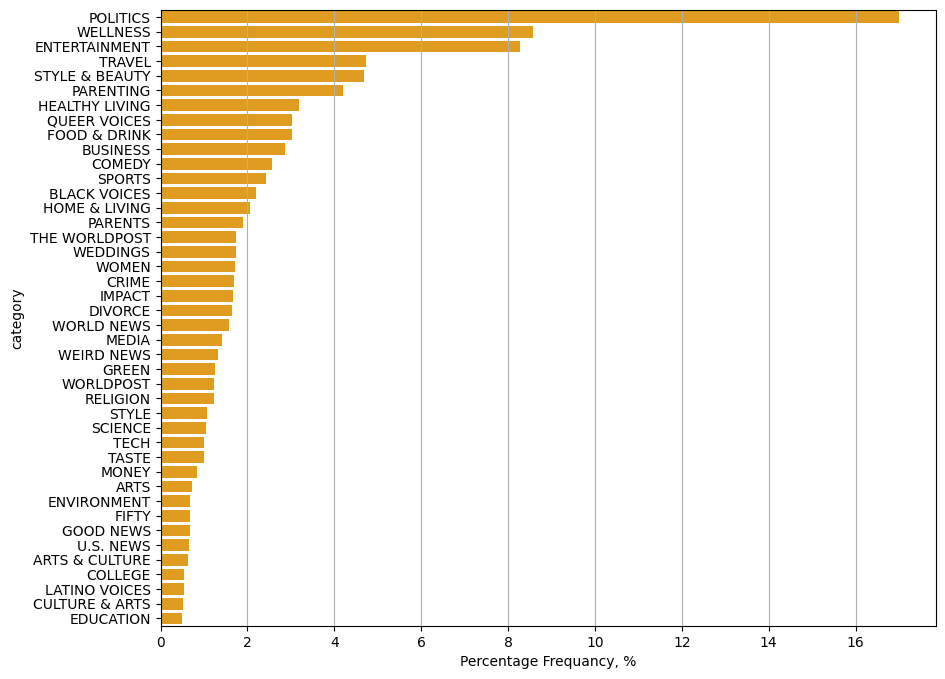

In [11]:
value_counts_plot(eda_data.category)

Наблюдается дисбаланс классов, не смотря на то что классов много, самый частый и наиболее редкий отличаются более чем в 10 раз. Однако это может быть важный, но не существенный разрыв. 

count    209514.000000
mean         19.669120
std          14.153197
min           0.000000
25%          10.000000
50%          19.000000
75%          24.000000
max         243.000000
Name: short_description, dtype: float64


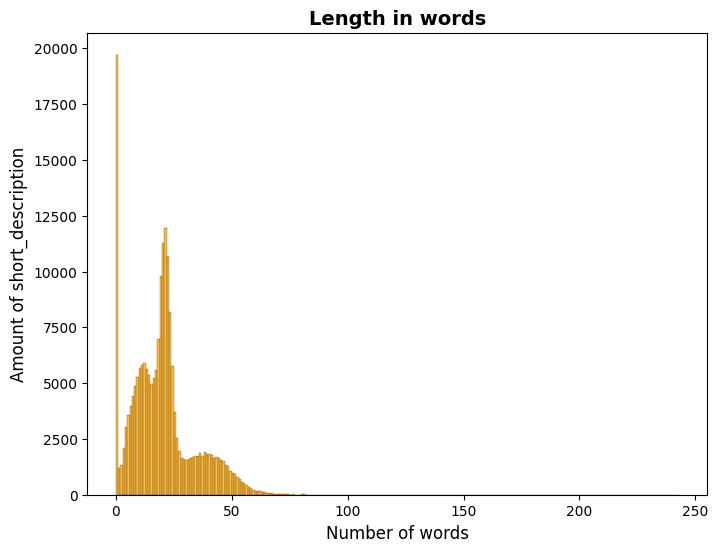

In [12]:
eda_data["description_len"] = word_count_plot(eda_data["short_description"], return_result=True)

In [13]:
eda_data.groupby('category')['description_len'].agg(['min', 'mean', 'median', 'max'])

,min,mean,median,max
category,,,,
ARTS,0,21.425447,26.0,106
ARTS & CULTURE,1,12.687080,12.0,43
BLACK VOICES,0,17.087715,17.0,101
BUSINESS,0,22.111148,21.0,143
COLLEGE,0,22.232517,19.0,182
COMEDY,0,12.593519,10.0,117
CRIME,0,13.860472,14.0,89
CULTURE & ARTS,0,25.293296,22.0,84
DIVORCE,5,25.761529,22.0,66


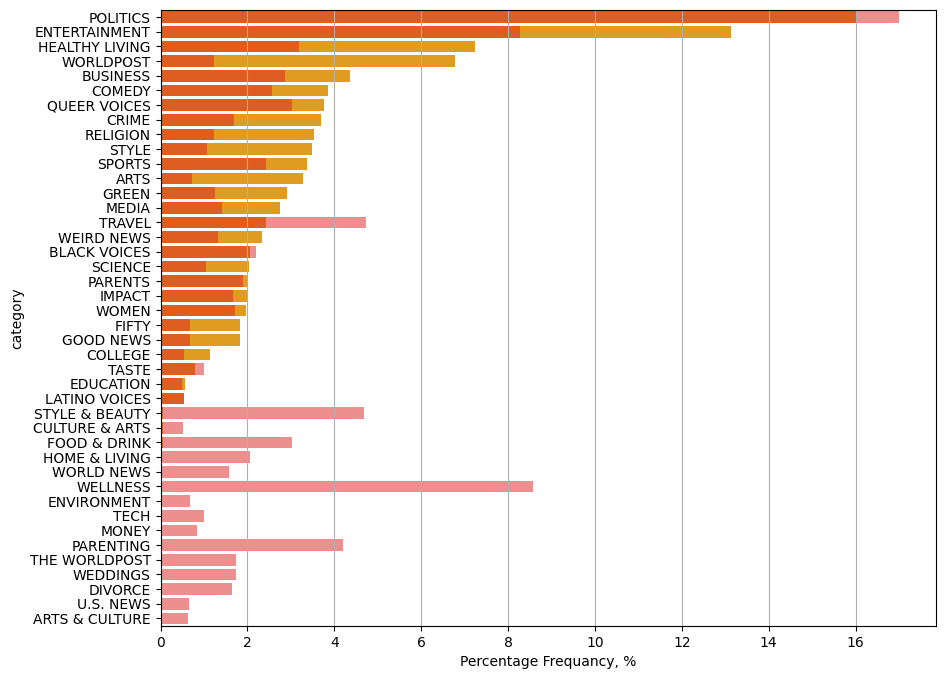

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
value_counts_plot(eda_data[eda_data["short_description"] == ""]["category"], ax=ax)
value_counts_plot(eda_data.category, ax=ax, alpha=0.5, color="red")

In [15]:
eda_data[(eda_data["short_description"] == "") & (eda_data["headline"] == "")]

,link,headline,category,short_description,authors,date,description_len
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22,0
103675,https://www.huffingtonpost.com/entry/us-and-eu...,,WORLDPOST,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29,0
109100,https://www.huffingtonpost.com/entry/disney-ce...,,BUSINESS,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25,0
110153,https://www.huffingtonpost.com/entry/beverly-h...,,MEDIA,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13,0
122145,https://www.huffingtonpost.com/entry/beverly-h...,,QUEER VOICES,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28,0


In [16]:
eda_data["description_tokenized_tiktoken"] = eda_data["short_description"].apply(tokenize_tiktoken)
eda_data["description_tokenized_tiktoken"]

0         [health, experts, said, it, is, too, early, to...
1         [he, was, subdued, by, passengers, and, crew, ...
2         [", until, you, have, a, dog, you, don, 't, un...
3         [", acc, identally, put, grown, -up, tooth, pa...
4         [amy, cooper, accused, investment, firm, frank...
                                ...                        
209522    [ver, izon, wireless, and, at, &t, are, alread...
209523    [after, ward, ,, az, aren, ka, ,, more, eff, u...
209524    [leading, up, to, super, bowl, xl, vi, ,, the,...
209525    [cor, re, ction, :, an, earlier, version, of, ...
209526    [the, five, -time, all, -star, center, tore, i...
Name: description_tokenized_tiktoken, Length: 209514, dtype: object

In [17]:
# eda_data['description_tokenized_tiktoken'] = eda_data['description_tokenized_tiktoken'].apply(generate_ngrams)
# eda_data['description_tokenized_tiktoken']

In [18]:
description_counts = count_tokens(eda_data["description_tokenized_tiktoken"])

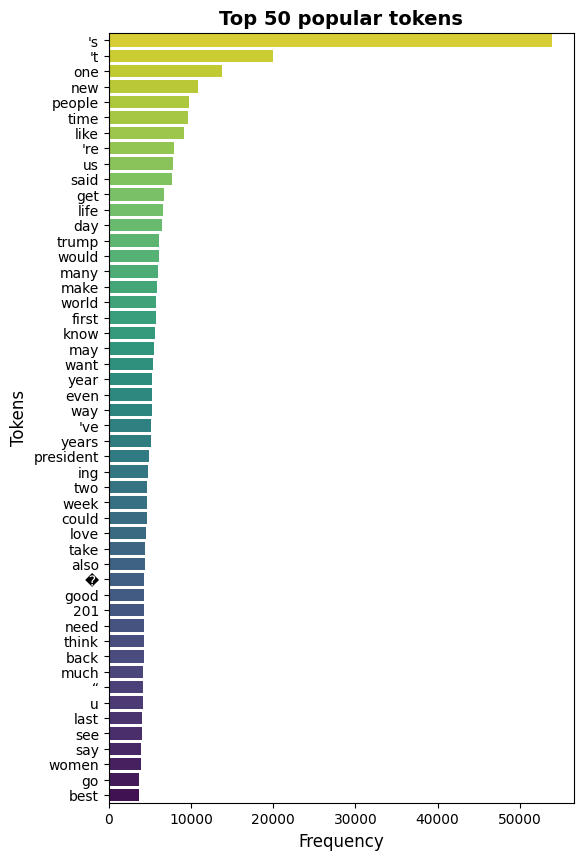

In [19]:
barplot(description_counts)

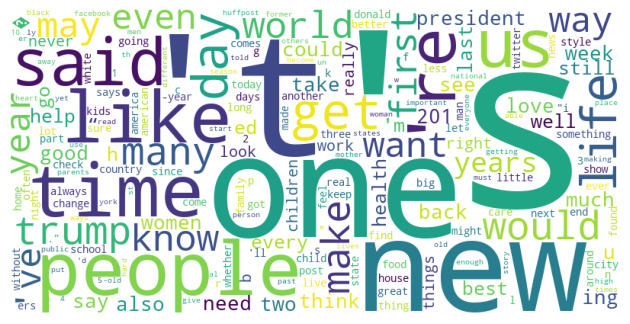

In [20]:
draw_wordcloud(description_counts)

count    209514.000000
mean          9.600762
std           3.068503
min           0.000000
25%           8.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: headline, dtype: float64


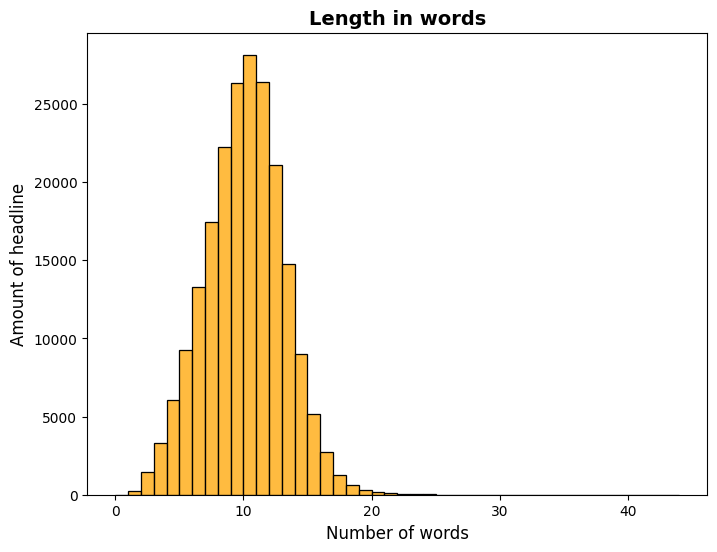

In [21]:
word_count_plot(eda_data["headline"])

In [20]:
eda_data["headline_tokenized_tiktoken"] = eda_data["headline"].apply(tokenize_tiktoken)
eda_data["headline_tokenized_tiktoken"]

0         [over, 4, million, americans, roll, up, slee, ...
1         [american, airlines, fly, er, charg, ed, ,, b,...
2         [23, of, the, fun, niest, tweets, about, cats,...
3         [the, fun, niest, tweets, from, parents, this,...
4         [woman, who, called, c, ops, on, black, bird, ...
                                ...                        
209522    [r, im, ceo, thor, sten, he, ins, ', ', sign, ...
209523    [maria, shar, ap, ova, st, unned, by, victoria...
209524    [gi, ants, over, patriots, ,, jets, over, colt...
209525    [a, ld, on, smith, arrest, ed, :, 49, ers, lin...
209526    [d, w, ight, howard, r, ips, team, mates, afte...
Name: headline_tokenized_tiktoken, Length: 209514, dtype: object

In [21]:
headline_counts = count_tokens(eda_data["headline_tokenized_tiktoken"])

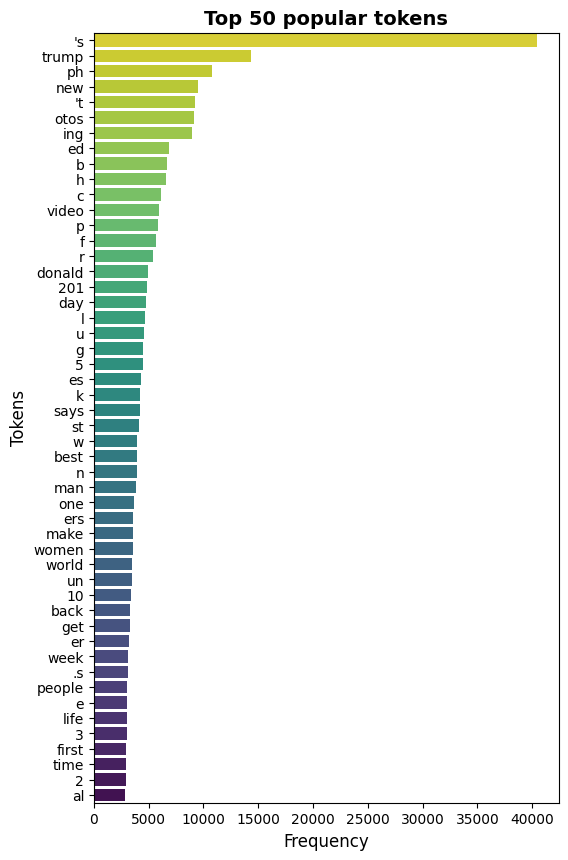

In [31]:
barplot(headline_counts)

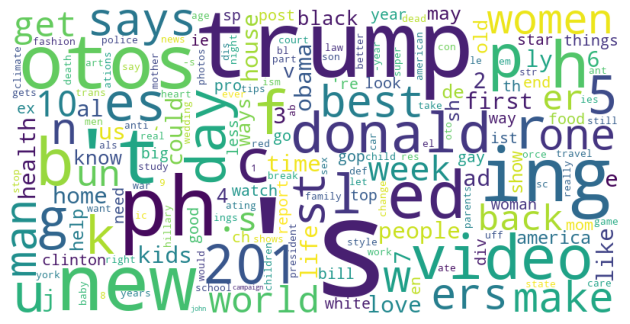

In [23]:
draw_wordcloud(headline_counts)

In [ ]:
eda_data["authors"].nunique()

29169

count    209514.000000
mean          4.099855
std           3.934197
min           0.000000
25%           2.000000
50%           2.000000
75%           7.000000
max          20.000000
Name: authors, dtype: float64


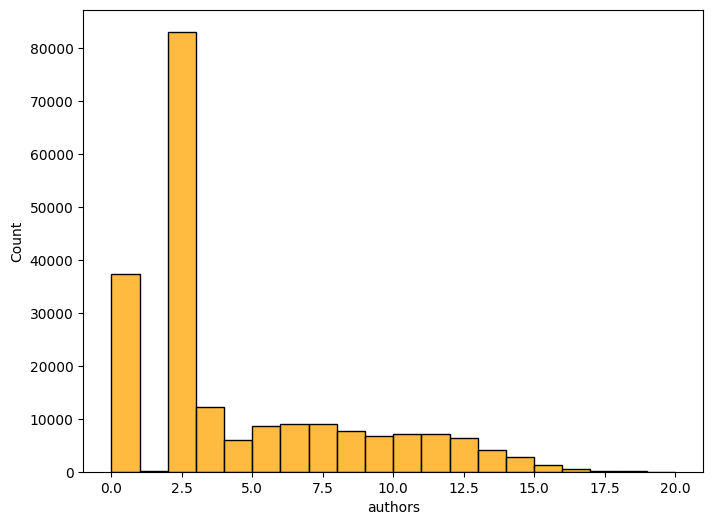

In [ ]:
word_count_plot(eda_data["authors"])

In [ ]:
import nltk 
import tiktoken
from collections import Counter
from nltk.corpus import stopwords
import string
from typing import Sequence, Any

TIKTOKEN_ENCODING = tiktoken.get_encoding('cl100k_base')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

In [ ]:
def tokenize_tiktoken(text: str) -> list[str]:
    token_bytes = [
        TIKTOKEN_ENCODING.decode_single_token_bytes(token)
        for token in TIKTOKEN_ENCODING.encode(text)
    ]

    tokens = [token.decode('utf-8', errors='replace').strip().lower() for token in token_bytes]
    return [token for token in tokens if token]

def filter_tokens(tokens:Sequence[str],
                  *,
                  remove_stopwords: bool = True,
                  remove_punctuation: bool = True,
                  custom_stopwords: set[str] = None,
                  custom_punctuation: set[str] = None,
                  lowercase_for_counting: bool = True,
                  language: str = 'english',
                  ) -> list[str]:
    
    stopwords_set = set(stopwords.words(language)) if custom_stopwords is None else custom_stopwords if remove_stopwords is True else None
    punctuation_set = set(string.punctuation) if custom_punctuation is None else custom_punctuation if remove_punctuation is True else None

    result = []

    for token in tokens:
        token = str(token).strip()
        if token == '':
            continue
        if remove_punctuation and (token in punctuation_set or all(c in punctuation_set for c in token)):
            continue
        if remove_stopwords and (token in stopwords_set or all(c in stopwords_set for c in token.split())):
            continue

        result.append(token.lower()) if lowercase_for_counting else result.append(token)

    return result



In [ ]:
short_description = eda_data["short_description"].apply(tokenize_tiktoken)
short_description

0         [health, experts, said, it, is, too, early, to...
1         [he, was, subdued, by, passengers, and, crew, ...
2         [", until, you, have, a, dog, you, don, 't, un...
3         [", acc, identally, put, grown, -up, tooth, pa...
4         [amy, cooper, accused, investment, firm, frank...
                                ...                        
209522    [ver, izon, wireless, and, at, &t, are, alread...
209523    [after, ward, ,, az, aren, ka, ,, more, eff, u...
209524    [leading, up, to, super, bowl, xl, vi, ,, the,...
209525    [cor, re, ction, :, an, earlier, version, of, ...
209526    [the, five, -time, all, -star, center, tore, i...
Name: short_description, Length: 209514, dtype: object

In [17]:
count_tokens(short_description)

NameError: name 'count_tokens' is not defined

In [41]:
total_counts = Counter()
for tokens in short_description:
    tokens = filter_tokens(tokens)
    total_counts.update(tokens)
total_counts

Counter({"'s": 53888,
         "'t": 20029,
         'one': 13718,
         'new': 10863,
         'people': 9777,
         'time': 9581,
         'like': 9116,
         "'re": 7994,
         'us': 7853,
         'said': 7663,
         'get': 6712,
         'life': 6555,
         'day': 6481,
         'trump': 6074,
         'would': 6067,
         'many': 5999,
         'make': 5909,
         'world': 5805,
         'first': 5767,
         'know': 5576,
         'may': 5457,
         'want': 5422,
         'year': 5240,
         'even': 5235,
         'way': 5217,
         "'ve": 5186,
         'years': 5179,
         'president': 4911,
         'ing': 4802,
         'two': 4689,
         'week': 4658,
         'could': 4607,
         'love': 4499,
         'take': 4463,
         'also': 4352,
         '�': 4321,
         'good': 4318,
         '201': 4317,
         'need': 4281,
         'think': 4265,
         'back': 4234,
         'much': 4220,
         '“': 4117,
         'u': 41

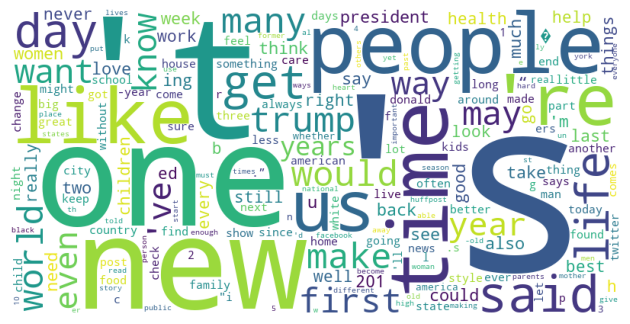

In [43]:
draw_wordcloud(total_counts)

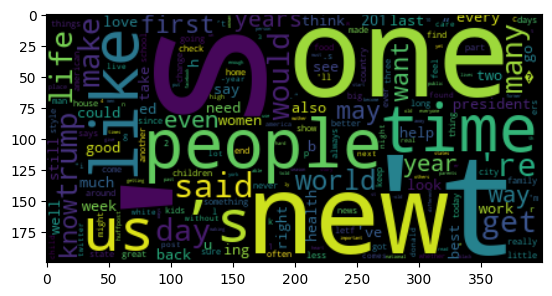

In [ ]:



wc = WordCloud().generate_from_frequencies(total_counts)
plt.imshow(wc, interpolation="bilinear")
plt.show()

In [28]:
eda_data['short_description'][0]

'Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.'

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),    # биграммы дают большой прирост
    sublinear_tf=True,     # log(tf) вместо tf — стандарт для текстов
    min_df=3,
    analyzer='word'
)
X_train_tfidf = tfidf.fit_transform(eda_data['short_description'])

In [ ]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (1, 100000)>

In [37]:
for col in data.columns:
    print(data[data[col] == ''][col].count())

0
6
0
19712
37418
0


In [45]:
data.loc[0, "short_description"]

'Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.'

In [57]:
import tiktoken

TIKTOKEN_ENCODING = tiktoken.get_encoding("cl100k_base")

text = data.loc[0, "short_description"]

token_bytes = [
        TIKTOKEN_ENCODING.decode_single_token_bytes(token)
        for token in TIKTOKEN_ENCODING.encode(text)
    ]

tokens = [token.decode('utf-8', errors='replace').strip().lower() for token in token_bytes]
[token for token in tokens if token]

['health',
 'experts',
 'said',
 'it',
 'is',
 'too',
 'early',
 'to',
 'predict',
 'whether',
 'demand',
 'would',
 'match',
 'up',
 'with',
 'the',
 '171',
 'million',
 'doses',
 'of',
 'the',
 'new',
 'boost',
 'ers',
 'the',
 'u',
 '.s',
 '.',
 'ordered',
 'for',
 'the',
 'fall',
 '.']